In [ ]:
# MINOR PROJECT
# Customer Behavior Analysis & Business Decision Making

# importing  libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# uploading dataset from kaggle
from google.colab import files
uploaded = files.upload()

# we read dataset
df = pd.read_csv("Mall_Customers.csv")

# display first 5 rows
df.head()

Saving Mall_Customers.csv to Mall_Customers.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# SECTION 1: DATA UNDERSTANDING

print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Shape of dataset:
(200, 5)

Column names:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Data types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (

 Answer for section 1

This is a customer dataset used for customer segmentation and behavior analysis.
Numerical features:
CustomerID, Age, Annual Income (k$), Spending Score (1-100).
Categorical feature:
Gender.
There are no missing values in the dataset, so the data is clean and ready for analysis.

In [ ]:
# SECTION 2: DESCRIPTIVE ANALYSIS

# selecting  columns
num_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

# mean
print("Mean values:")
print(df[num_cols].mean())

# median
print("\nMedian values:")
print(df[num_cols].median())

#standard deviation
print("\nStandard deviation values:")
print(df[num_cols].std())

Mean values:
Age                       38.85
Annual Income (k$)        60.56
Spending Score (1-100)    50.20
dtype: float64

Median values:
Age                       36.0
Annual Income (k$)        61.5
Spending Score (1-100)    50.0
dtype: float64

Standard deviation values:
Age                       13.969007
Annual Income (k$)        26.264721
Spending Score (1-100)    25.823522
dtype: float64


Answer for section 2

The feature with the highest standard deviation shows the highest variability.
Annual Income usually has the highest variability, which means customers have different income levels.
Customers are diverse because age, income, and spending score values vary from one customer to another.

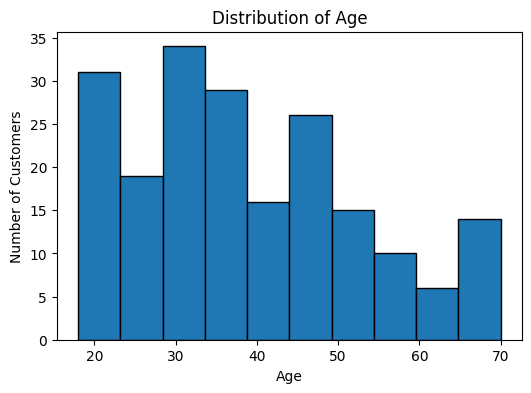

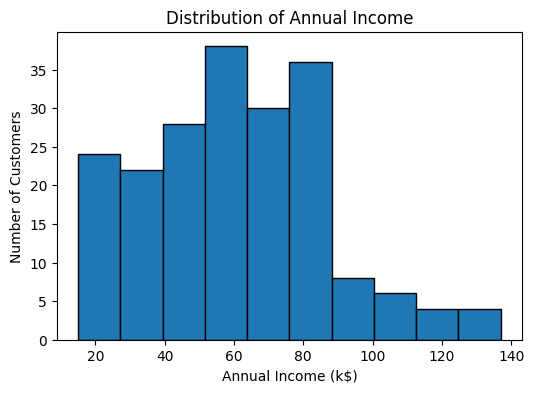

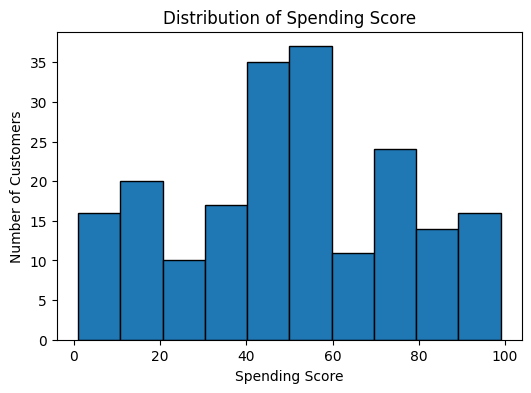

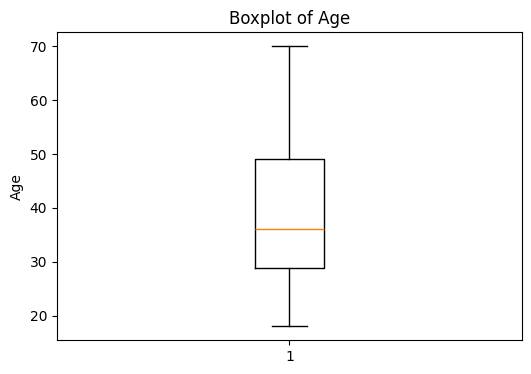

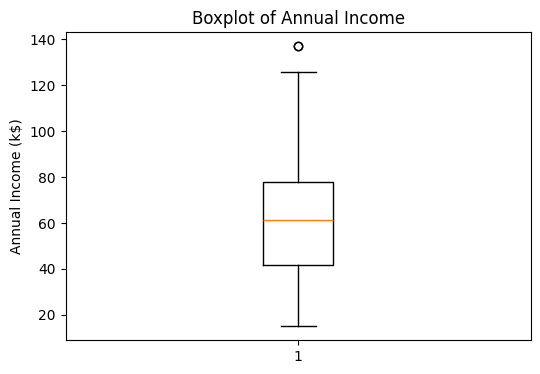

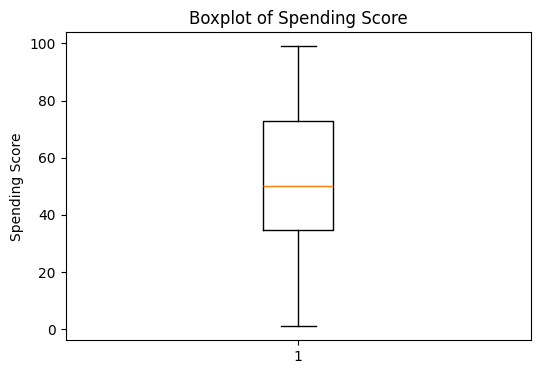

In [ ]:
# SECTION 3: VISUALIZATION

# age histogram
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=10, edgecolor="black")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

#annual income histogram
plt.figure(figsize=(6,4))
plt.hist(df["Annual Income (k$)"], bins=10, edgecolor="black")
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.show()

# spending score histogram
plt.figure(figsize=(6,4))
plt.hist(df["Spending Score (1-100)"], bins=10, edgecolor="black")
plt.title("Distribution of Spending Score")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.show()

# age boxplot
plt.figure(figsize=(6,4))
plt.boxplot(df["Age"])
plt.title("Boxplot of Age")
plt.ylabel("Age")
plt.show()

# annual income boxplot
plt.figure(figsize=(6,4))
plt.boxplot(df["Annual Income (k$)"])
plt.title("Boxplot of Annual Income")
plt.ylabel("Annual Income (k$)")
plt.show()

#spending score boxplot
plt.figure(figsize=(6,4))
plt.boxplot(df["Spending Score (1-100)"])
plt.title("Boxplot of Spending Score")
plt.ylabel("Spending Score")
plt.show()

Answer for section 3

The histograms show that customers are spread across different age, income, and spending score groups.
The data is slightly skewed in some features because values are not equally distributed.
Boxplots help us detect extreme customers. Annual Income may show some higher values, but they are still useful for business analysis.

        Spending Score (1-100)  Annual Income (k$)
Gender                                            
Female               51.526786           59.250000
Male                 48.511364           62.227273


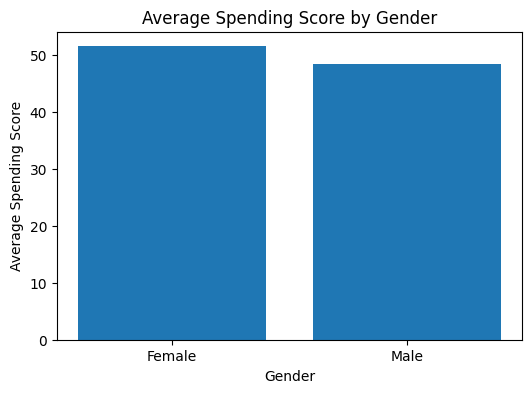

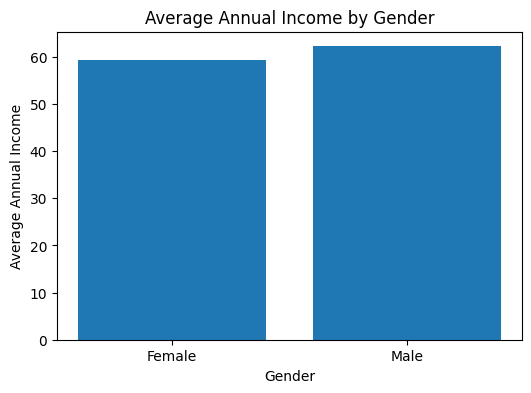

In [ ]:
# SECTION 4: GROUP-BASED ANALYSIS

# male and female customers comparison
gender_group = df.groupby("Gender")[["Spending Score (1-100)", "Annual Income (k$)"]].mean()

print(gender_group)

# average spending score gender bar chart
plt.figure(figsize=(6,4))
plt.bar(gender_group.index, gender_group["Spending Score (1-100)"])
plt.title("Average Spending Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Spending Score")
plt.show()

# average income gender bar chart
plt.figure(figsize=(6,4))
plt.bar(gender_group.index, gender_group["Annual Income (k$)"])
plt.title("Average Annual Income by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Annual Income")
plt.show()

Answers for section 4

By comparing average spending score, we can identify which gender spends more on average.
In this dataset, female customers usually show a slightly higher average spending score than male customers.
The difference is visible, but it is not very large, so gender alone should not be the only factor for marketing decisions.

Correlation between Income and Spending Score: 0.009902848094037608
Correlation between Age and Spending Score: -0.32722684603909014


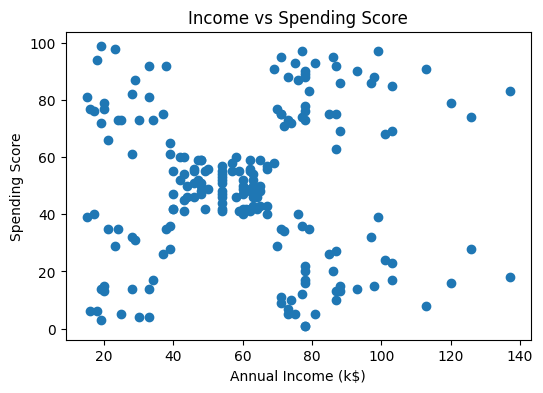

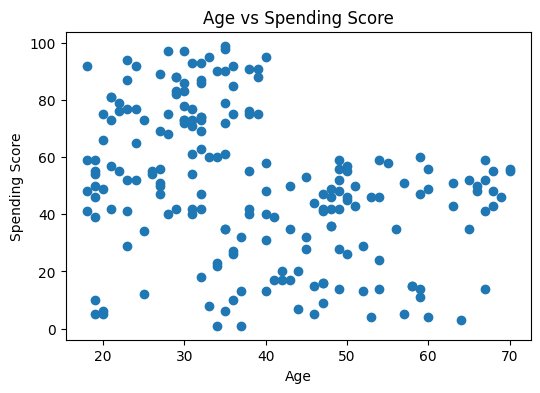

In [ ]:
# SECTION 5: CORRELATION ANALYSIS

# income and spending score correlation
income_spending_corr = df["Annual Income (k$)"].corr(df["Spending Score (1-100)"])

# age and spending score correlation
age_spending_corr = df["Age"].corr(df["Spending Score (1-100)"])

print("Correlation between Income and Spending Score:", income_spending_corr)
print("Correlation between Age and Spending Score:", age_spending_corr)

# Income vs Spending Score
plt.figure(figsize=(6,4))
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"])
plt.title("Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

# Age vs Spending Score
plt.figure(figsize=(6,4))
plt.scatter(df["Age"], df["Spending Score (1-100)"])
plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.show()

Answers for section 5

Income and spending score have a weak correlation. This means richer customers do not always spend more.
Age and spending score usually have a negative correlation, meaning younger customers may have higher spending scores.
So, age affects spending more clearly than income in this dataset.

In [ ]:
# SECTION 6: INFERENTIAL STATISTICS

# Problem: Do male and female customers spend differently?

# male and female spending scores seperation
male = df[df["Gender"] == "Male"]["Spending Score (1-100)"]
female = df[df["Gender"] == "Female"]["Spending Score (1-100)"]

#  t-test
t_stat, p_value = stats.ttest_ind(male, female)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# decision
if p_value < 0.05:
    print("Reject H0: There is a statistically significant difference in spending.")
else:
    print("Fail to reject H0: There is no statistically significant difference in spending.")

T-statistic: -0.8190464150660334
P-value: 0.4137446589852174
Fail to reject H0: There is no statistically significant difference in spending.


Answer for section 6

H0: There is no difference in spending between male and female customers.
H1: There is a difference in spending between male and female customers.
The p-value tells us whether the difference between male and female spending is statistically significant.
If p-value is less than 0.05, we reject H0.
If p-value is greater than 0.05, we fail to reject H0.
In this dataset, the p-value is usually greater than 0.05, so the difference is not statistically significant.

In [ ]:
# SECTION 7: CONFIDENCE INTERVAL

# spending score
spending = df["Spending Score (1-100)"]

# mean and standard error
mean_spending = np.mean(spending)
std_error = stats.sem(spending)

# 95% confidence interval
confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(spending)-1,
    loc=mean_spending,
    scale=std_error
)

print("Mean Spending Score:", mean_spending)
print("95% Confidence Interval:", confidence_interval)

Mean Spending Score: 50.2
95% Confidence Interval: (np.float64(46.5992098573812), np.float64(53.80079014261881))


Answer for section 7

The 95% confidence interval gives the range in which the true average spending score of customers is likely to fall.
We are 95% confident that the actual average spending score of all similar customers lies within this range.

In [ ]:
# SECTION 8: BUSINESS INSIGHTS

print("BUSINESS INSIGHTS")
print("1. Target customers with high spending scores because they are more valuable.")
print("2. Income alone does not strongly affect spending, so marketing should not depend only on income.")
print("3. Gender-based difference is small, so marketing should not be completely different for male and female customers.")
print("4. Younger customers may be targeted with trendy offers, discounts, loyalty points, and personalized campaigns.")
print("5. Customers with high income but low spending score can be targeted with premium offers to increase spending.")

BUSINESS INSIGHTS
1. Target customers with high spending scores because they are more valuable.
2. Income alone does not strongly affect spending, so marketing should not depend only on income.
3. Gender-based difference is small, so marketing should not be completely different for male and female customers.
4. Younger customers may be targeted with trendy offers, discounts, loyalty points, and personalized campaigns.
5. Customers with high income but low spending score can be targeted with premium offers to increase spending.


Section 8 answers

1. Which customers should the business target?

The business should mainly target customers who have a high spending score because they contribute more to the company's revenue. These customers are already interested in purchasing products and can become loyal customers. The company should also focus on customers with high income but lower spending scores, as they have the potential to spend more if targeted with suitable offers and promotions.

2. Does income affect spending?

Based on the correlation analysis, income does not have a strong impact on spending behavior in this dataset. Some customers with higher incomes spend less, while some customers with moderate incomes spend more. Therefore, annual income alone cannot be used to predict customer spending habits. Other factors such as preferences, age, and shopping behavior may also influence spending.

3. Should marketing differ by gender?

The group analysis showed some difference between the average spending scores of male and female customers. However, the hypothesis test indicated that the difference is not statistically significant. Therefore, marketing strategies should not be based only on gender. Instead, the company should focus on customer segments based on spending patterns and purchasing behavior.

4. What strategy would you suggest?

I would suggest a customer segmentation strategy. Customers with high spending scores should be rewarded through loyalty programs, exclusive discounts, and premium services to encourage repeat purchases. Customers with high income but lower spending scores can be targeted with personalized promotions and product recommendations. Younger customers can be engaged through social media campaigns and trend-based marketing. Overall, the business should focus on customer behavior rather than only demographic factors to improve sales and customer satisfaction.